# Satellite Image Classification — EfficientNetB0 + Quantization (TensorFlow)

## 1. Imports

In [1]:
import os, shutil, time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing import image_dataset_from_directory
from sklearn.metrics import classification_report, confusion_matrix

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
print("TF version:", tf.__version__)
print("GPU available:", len(gpus) > 0)

TF version: 2.20.0
GPU available: True


## 2. Kaggle Setup

In [2]:
from google.colab import files
files.upload()

Saving kaggle3.json to kaggle3 (1).json


{'kaggle3 (1).json': b'{"username":"rambhadrakumar","key":"32c81b7b282d0e78edb892f9a59b7c1b"}'}

In [3]:
os.makedirs('/root/.kaggle', exist_ok=True)
os.system('cp kaggle.json /root/.kaggle/')
os.system('chmod 600 /root/.kaggle/kaggle.json')
os.system('kaggle datasets download -d mahmoudreda55/satellite-image-classification --unzip -p /content/satellite')
print("Download complete!")
print(sorted(os.listdir('/content/satellite')))

Download complete!
['data']


## 3. Config

In [4]:
DATA_DIR = '/content/satellite/data'
IMG_SIZE    = 224
BATCH_SIZE  = 32
EPOCHS_P1 = 20
EPOCHS_P2 = 20
AUTOTUNE    = tf.data.AUTOTUNE

print("Classes found:", sorted(os.listdir(DATA_DIR)))
NUM_CLASSES = len(os.listdir(DATA_DIR))
print("Number of classes:", NUM_CLASSES)

Classes found: ['cloudy', 'desert', 'green_area', 'water']
Number of classes: 4


## 4. Data Loaders

In [5]:
train_ds = image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset='training',
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

val_ds = image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset='validation',
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print("Classes:", class_names)
print("Train batches:", len(train_ds))
print("Val batches  :", len(val_ds))

Found 5631 files belonging to 4 classes.
Using 4505 files for training.
Found 5631 files belonging to 4 classes.
Using 1126 files for validation.
Classes: ['cloudy', 'desert', 'green_area', 'water']
Train batches: 141
Val batches  : 36


In [6]:
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)

## 5. Sample Images

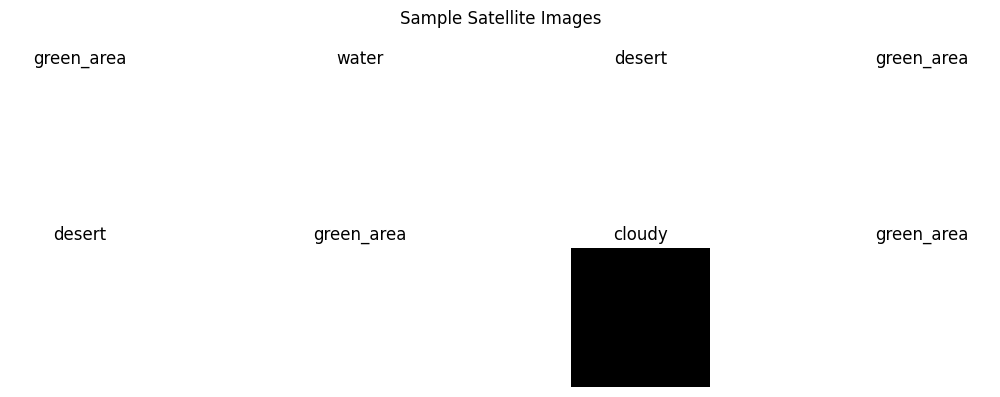

In [7]:
plt.figure(figsize=(12, 4))
for images, labels in train_ds.take(1):
    for i in range(min(8, images.shape[0])):
        plt.subplot(2, 4, i+1)
        plt.imshow(images[i].numpy())
        plt.title(class_names[labels[i]])
        plt.axis('off')
plt.suptitle('Sample Satellite Images')
plt.tight_layout()
plt.show()

## 6. Build EfficientNetB0 Model

In [8]:
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal_and_vertical'),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False

inputs  = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x       = data_augmentation(inputs)
x       = tf.keras.applications.efficientnet.preprocess_input(x)  # ADD THIS
x       = base_model(x, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dense(512, activation='relu',
                        kernel_initializer='he_normal',
                        kernel_regularizer=regularizers.l2(1e-4))(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dropout(0.3)(x)
x       = layers.Dense(256, activation='relu',
                        kernel_initializer='he_normal',
                        kernel_regularizer=regularizers.l2(1e-4))(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dropout(0.2)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax',
                        kernel_initializer='glorot_uniform')(x)

model = keras.Model(inputs, outputs)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,845,991 (18.49 MB)

 Trainable params: 792,324 (3.02 MB)

 Non-trainable params: 4,053,667 (15.46 MB)

## 7. Phase 1 — Train Classifier Head

In [9]:
callbacks_p1 = [
    keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7),
    keras.callbacks.ModelCheckpoint('best_model_p1.keras', monitor='val_accuracy', save_best_only=True)
]

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("=== PHASE 1: Training classifier head ===")
history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_P1,
    callbacks=callbacks_p1
)

=== PHASE 1: Training classifier head ===
Epoch 1/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 35s 140ms/step - accuracy: 0.9756 - loss: 0.2199 - val_accuracy: 0.9858 - val_loss: 0.2235 - learning_rate: 0.0010
Epoch 2/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 14s 98ms/step - accuracy: 0.9918 - loss: 0.1766 - val_accuracy: 0.9973 - val_loss: 0.1697 - learning_rate: 0.0010
Epoch 3/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 14s 98ms/step - accuracy: 0.9916 - loss: 0.1755 - val_accuracy: 0.9991 - val_loss: 0.1507 - learning_rate: 0.0010
Epoch 4/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 13s 91ms/step - accuracy: 0.9933 - loss: 0.1617 - val_accuracy: 0.9991 - val_loss: 0.1446 - learning_rate: 0.0010
Epoch 5/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 14s 96ms/step - accuracy: 0.9925 - loss: 0.1604 - val_accuracy: 1.0000 - val_loss: 0.1359 - learning_rate: 0.0010
Epoch 6/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 13s 91ms/step - accuracy: 0.9927 - loss: 0.1536 - val_accuracy: 0.9973 - val_loss: 0.1359 - learning_rate: 0.0010
Epoch 7/20
141/141 ━━━━━━━━━━━━━━

## 8. Phase 2 — Fine-tune Top Layers

In [10]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

callbacks_p2 = [
    keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, min_lr=1e-8),
    keras.callbacks.ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True)
]

model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("=== PHASE 2: Fine-tuning top 30 layers ===")
history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_P2,
    callbacks=callbacks_p2
)

=== PHASE 2: Fine-tuning top 30 layers ===
Epoch 1/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 35s 133ms/step - accuracy: 0.8701 - loss: 0.6266 - val_accuracy: 0.9858 - val_loss: 0.1798 - learning_rate: 1.0000e-05
Epoch 2/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 15s 107ms/step - accuracy: 0.9485 - loss: 0.2899 - val_accuracy: 0.9822 - val_loss: 0.1835 - learning_rate: 1.0000e-05
Epoch 3/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 15s 106ms/step - accuracy: 0.9711 - loss: 0.2299 - val_accuracy: 0.9858 - val_loss: 0.1701 - learning_rate: 1.0000e-05
Epoch 4/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 16s 112ms/step - accuracy: 0.9774 - loss: 0.2112 - val_accuracy: 0.9876 - val_loss: 0.1640 - learning_rate: 1.0000e-05
Epoch 5/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 16s 113ms/step - accuracy: 0.9769 - loss: 0.1988 - val_accuracy: 0.9902 - val_loss: 0.1592 - learning_rate: 1.0000e-05
Epoch 6/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 16s 111ms/step - accuracy: 0.9825 - loss: 0.1995 - val_accuracy: 0.9929 - val_loss: 0.1552 - learning_rate: 1.0000e-05
Epo

## 9. Training Curves

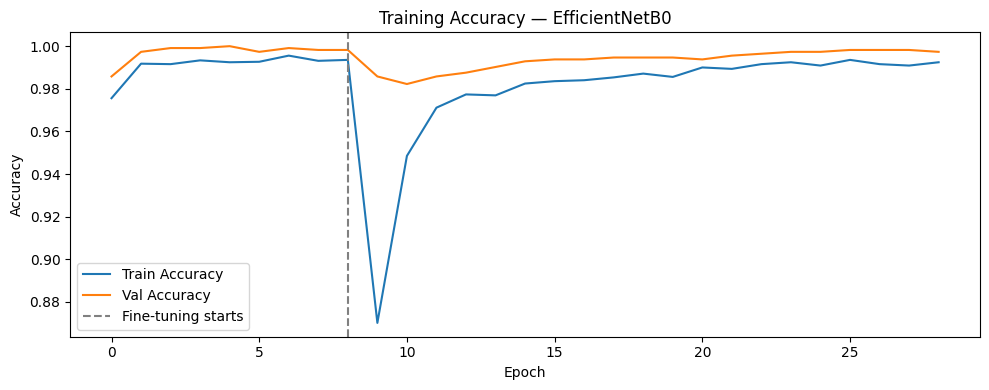

In [11]:
all_acc  = history1.history['accuracy']  + history2.history['accuracy']
all_vacc = history1.history['val_accuracy'] + history2.history['val_accuracy']

plt.figure(figsize=(10, 4))
plt.plot(all_acc,  label='Train Accuracy')
plt.plot(all_vacc, label='Val Accuracy')
plt.axvline(x=len(history1.history['accuracy']) - 1, color='gray', linestyle='--', label='Fine-tuning starts')
plt.title('Training Accuracy — EfficientNetB0')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

## 10. Load Best Model & Evaluate

In [12]:
model = keras.models.load_model('best_model.keras')

orig_loss, orig_acc = model.evaluate(val_ds)
print(f"Original Model — Loss: {orig_loss:.4f}  Accuracy: {orig_acc*100:.2f}%")

36/36 ━━━━━━━━━━━━━━━━━━━━ 8s 66ms/step - accuracy: 0.9982 - loss: 0.1410
Original Model — Loss: 0.1410  Accuracy: 99.82%


## 11. Save Original Model

In [13]:
model.save('satellite_efficientnet.keras')
orig_size = os.path.getsize('satellite_efficientnet.keras') / (1024 * 1024)
print(f"Original Model Size: {orig_size:.2f} MB")

Original Model Size: 36.80 MB


## 12. Post-Training Quantization (TFLite INT8)

In [15]:
def representative_dataset():
    for images, _ in train_ds.take(10):  # reduced from 200 to 10
        for img in images:
            yield [tf.expand_dims(img, 0)]

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type  = tf.float32
converter.inference_output_type = tf.float32
converter.experimental_new_converter = True
converter._experimental_lower_tensor_list_ops = False

tflite_model = converter.convert()

with open('satellite_efficientnet_quantized.tflite', 'wb') as f:
    f.write(tflite_model)

quant_size = os.path.getsize('satellite_efficientnet_quantized.tflite') / (1024 * 1024)
print(f"Quantized Model Size: {quant_size:.2f} MB")
print(f"Size Reduction      : {((orig_size - quant_size) / orig_size) * 100:.1f}%")

Saved artifact at '/tmp/tmpg09e55yc'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  133133498109392: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  133133498120336: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  133133485683344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133133485684496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133133485684688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133133485685456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133133485686032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133133485686224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133133485682384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133133485685264: TensorSpec(shape=(), dtype=tf.resource, name=Non

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Quantized Model Size: 5.45 MB
Size Reduction      : 85.2%


## 13. Evaluate Quantized Model

In [16]:
interpreter = tf.lite.Interpreter(model_path='satellite_efficientnet_quantized.tflite', num_threads=4)
interpreter.allocate_tensors()

input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()

def evaluate_tflite(interp, dataset):
    correct = 0
    total   = 0
    start   = time.time()
    for images, labels in dataset:
        for img, label in zip(images.numpy(), labels.numpy()):
            img_input = np.expand_dims(img, axis=0).astype(np.float32)
            interp.set_tensor(input_details[0]['index'], img_input)
            interp.invoke()
            output  = interp.get_tensor(output_details[0]['index'])
            pred    = np.argmax(output)
            correct += int(pred == label)
            total   += 1
    elapsed = time.time() - start
    return (correct / total) * 100, elapsed

quant_acc, quant_time = evaluate_tflite(interpreter, val_ds)
print(f"Quantized — Accuracy: {quant_acc:.2f}%  |  Inference Time: {quant_time:.2f}s")

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Quantized — Accuracy: 57.37%  |  Inference Time: 41.04s


## 14. Comparison

In [17]:
start = time.time()
model.evaluate(val_ds, verbose=0)
orig_time = time.time() - start

print(f"Original  — Size: {orig_size:.2f} MB  |  Accuracy: {orig_acc*100:.2f}%  |  Time: {orig_time:.2f}s")
print(f"Quantized — Size: {quant_size:.2f} MB  |  Accuracy: {quant_acc:.2f}%  |  Time: {quant_time:.2f}s")

Original  — Size: 36.80 MB  |  Accuracy: 99.82%  |  Time: 2.52s
Quantized — Size: 5.45 MB  |  Accuracy: 57.37%  |  Time: 41.04s


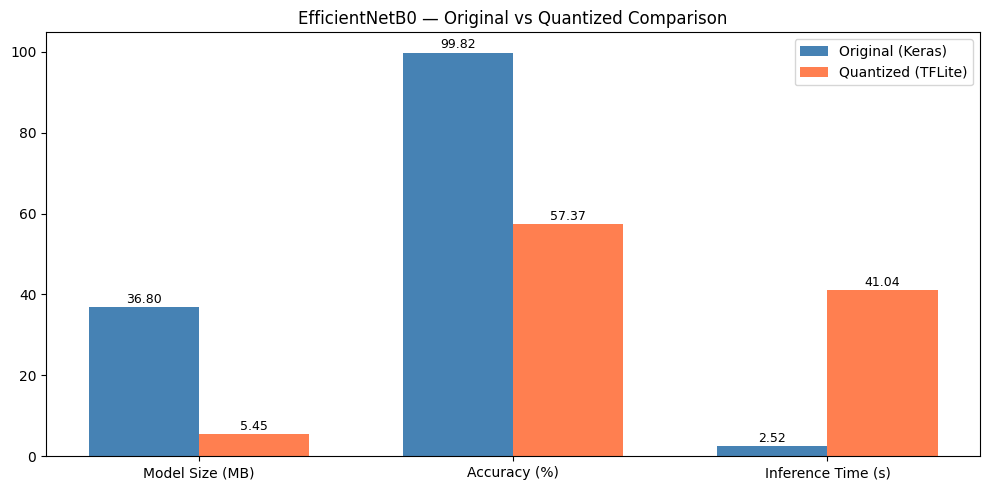

In [18]:
categories = ['Model Size (MB)', 'Accuracy (%)', 'Inference Time (s)']
orig_vals  = [orig_size, orig_acc * 100, orig_time]
quant_vals = [quant_size, quant_acc, quant_time]

x     = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, orig_vals,  width, label='Original (Keras)',    color='steelblue')
bars2 = ax.bar(x + width/2, quant_vals, width, label='Quantized (TFLite)',  color='coral')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_title('EfficientNetB0 — Original vs Quantized Comparison')
ax.legend()
for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

## 15. Confusion Matrix

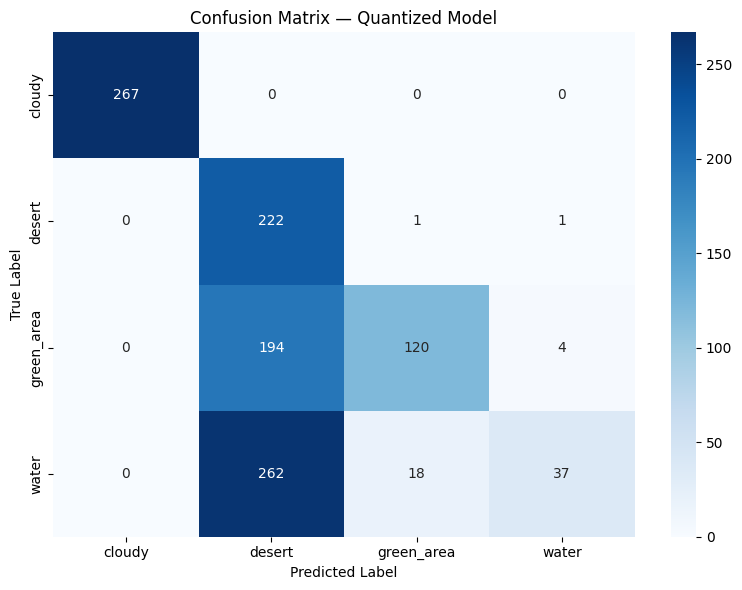

              precision    recall  f1-score   support

      cloudy       1.00      1.00      1.00       267
      desert       0.33      0.99      0.49       224
  green_area       0.86      0.38      0.53       318
       water       0.88      0.12      0.21       317

    accuracy                           0.57      1126
   macro avg       0.77      0.62      0.56      1126
weighted avg       0.79      0.57      0.54      1126



In [19]:
all_preds  = []
all_labels = []

for images, labels in val_ds:
    for img, label in zip(images.numpy(), labels.numpy()):
        img_input = np.expand_dims(img, axis=0).astype(np.float32)
        interpreter.set_tensor(input_details[0]['index'], img_input)
        interpreter.invoke()
        output = interpreter.get_tensor(output_details[0]['index'])
        all_preds.append(np.argmax(output))
        all_labels.append(label)

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.title('Confusion Matrix — Quantized Model')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print(classification_report(all_labels, all_preds, target_names=class_names))

## 16. Download Models

In [20]:
print("Models saved:")
print(" -", os.path.abspath('satellite_efficientnet.keras'))
print(" -", os.path.abspath('satellite_efficientnet_quantized.tflite'))

Models saved:
 - /content/satellite_efficientnet.keras
 - /content/satellite_efficientnet_quantized.tflite
